# Working with the ``zea`` data format
In this tutorial notebook we will show how to load a zea data file and how to access the data stored in it. There are three common ways to load a zea data file:

1. Loading data from single file with `zea.File`
2. Loading data from a group of files with `zea.Dataset`
3. Loading data in batches with dataloading utilities with `zea.Dataloader`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_data_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_data_example.ipynb)
&nbsp;
[![Hugging Face dataset](https://img.shields.io/badge/Hugging%20Face-Dataset-yellow?logo=huggingface)](https://huggingface.co/datasets/zeahub/picmus)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
config_picmus_iq = "hf://zeahub/configs/config_picmus_iq.yaml"

In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import keras
import matplotlib.pyplot as plt

import zea
from zea.visualize import set_mpl_style

zea: Using backend 'jax'


We will work with the GPU if available, and initialize using `init_device` to pick the best available device. Also, (optionally), we will set the matplotlib style for plotting.

In [5]:
zea.init_device(verbose=False)
set_mpl_style()

## Loading a file with `zea.File`
The zea data format works with HDF5 files. We can open a zea data file using the `h5py` package and have a look at the contents using the `zea.File.summary()` function. You can see that every dataset element contains a corresponding description and unit. Note that we now pass a url to a Hugging Face dataset, but you can also use a local file path to a zea data file. Here we will use an example from the [PICMUS](https://www.creatis.insa-lyon.fr/Challenge/IEEE_IUS_2016/home) dataset, converted to zea format and hosted on the [Hugging Face Hub](https://huggingface.co/datasets/zeahub/picmus).

> *Tip:*
> You can also use the [HDFView](https://www.hdfgroup.org/downloads/hdfview/) tool to view the contents of the zea data file without having to run any code. Or if you use VS Code, you can install the [HDF5 extension](https://marketplace.visualstudio.com/items?itemName=h5web.vscode-h5web) to view the contents of the file.

You can extract data and acquisition parameters (which are stored together with the data in the zea data file) as follows:

In [6]:
file_path = "hf://zeahub/picmus/database/experiments/contrast_speckle/contrast_speckle_expe_dataset_iq/contrast_speckle_expe_dataset_iq.hdf5"

# we'll only load the first frame and the first 3 transmit events here
frame_idx = 0
transmit_idx = slice(0, 3)

with zea.File(file_path, mode="r", revision="v0.1.0") as file:
    file.summary()
    data = file.data.raw_data[frame_idx, transmit_idx]
    parameters = file.load_parameters()

print("Raw data shape:", data.shape)
print(parameters)

contrast_speckle_expe_dataset_iq.hdf5/
    ├── description: PICMUS (Plane-wave Imaging Challenge in Medical UltraSound) dataset converted to zea format. License: The datasets and code provided on PICMUS are free of use. The only request is to refer properly to PICMUS - The Plane Wave Imaging Challenge in Medical UltraSound and quote the proceeding paper.. Citation: H. Liebgott, A. Rodriguez-Molares, F. Cervenansky, J. D'hooge, O. Bernard. "Plane-Wave Imaging Challenge in Medical Ultrasound." 2016 IEEE International Ultrasonics Symposium (IUS), Tours, France, 2016, pp. 1-4. https://doi.org/10.1109/ULTSYM.2016.7728908
    ├── zea_version: 0.1.0
    ├── metadata/
    │   ├── credit/
    │   │   ├── /metadata/credit (shape=())
    │   │   │   ├── description: Credit or attribution for the dataset.
    │   │   │   ├── unit: -
    │   └── subject/
    │       └── type/
    │           ├── /metadata/subject/type (shape=())
    │           │   ├── description: 
    │           │   ├── unit: -


## Loading data with `zea.Dataset`
We can also load and manage a group of files (i.e. a dataset) using the `zea.Dataset` class. Instead of a path to a single file, we can pass a list of file paths or a directory containing multiple zea data files. The `zea.Dataset` class will automatically load the files and allow you to access the data in a similar way as with `zea.File`.

In [7]:
dataset_path = "hf://zeahub/picmus/database/experiments"

dataset = zea.Dataset(dataset_path, revision="v0.1.0")

print(dataset)

for file in dataset:
    print(file)

dataset.close()

database/experiments/contrast_speckle/co(…):   0%|          | 0.00/127M [00:00<?, ?B/s]

database/experiments/resolution_distorsi(…):   0%|          | 0.00/64.2M [00:00<?, ?B/s]

database/experiments/resolution_distorsi(…):   0%|          | 0.00/127M [00:00<?, ?B/s]

zea: Searching /root/.cache/zea/huggingface/datasets/datasets--zeahub--picmus/snapshots/07fe825b53c92b1d423fadb1dfa104ed2a38aa4a/database/experiments for ['.hdf5', '.h5'] files...
Dataset with 4 files
zea: WARNING This ``zea.File`` '/root/.cache/zea/huggingface/datasets/datasets--zeahub--picmus/snapshots/07fe825b53c92b1d423fadb1dfa104ed2a38aa4a/database/experiments/contrast_speckle/contrast_speckle_expe_dataset_rf/contrast_speckle_expe_dataset_rf.hdf5' was created with a legacy version of zea (<0.1.0), while you are using zea v0.1.0a1. It may behave in unexpected ways. Install an earlier version of zea<0.1.0 for full compatibility or re-save the file with zea v0.1.0 or later (e.g. via File.create).
<File "contrast_speckle_expe_dataset_rf.hdf5" (mode r, 1 track)>
zea: WARNING This ``zea.File`` '/root/.cache/zea/huggingface/datasets/datasets--zeahub--picmus/snapshots/07fe825b53c92b1d423fadb1dfa104ed2a38aa4a/database/experiments/contrast_speckle/contrast_speckle_expe_dataset_iq/contrast_s

## Loading data with `Dataloader`

In machine and deep learning workflows, we often want more features like batching, shuffling, and parallel data loading. The `zea.Dataloader` class provides a convenient way to create a high-performance data loader from a zea dataset. It is built on Grain and does not require TensorFlow. This dataloader is particularly useful for training models. Consistency of shape is preferred, which is not the case for [PICMUS](https://www.creatis.insa-lyon.fr/Challenge/IEEE_IUS_2016/home). Therefore in this example we will use a small part of the [CAMUS](https://www.creatis.insa-lyon.fr/Challenge/camus/) dataset.

val/patient0401/patient0401_2CH_half_seq(…):   0%|          | 0.00/24.9M [00:00<?, ?B/s]

val/patient0401/patient0401_4CH_half_seq(…):   0%|          | 0.00/25.1M [00:00<?, ?B/s]

zea: Searching /root/.cache/zea/huggingface/datasets/datasets--zeahub--camus-sample/snapshots/66df8da70a28be958531748b5d67530fe496943b/val for ['.hdf5', '.h5'] files...


zea: Dataset validated. Check /root/.cache/zea/huggingface/datasets/datasets--zeahub--camus-sample/snapshots/66df8da70a28be958531748b5d67530fe496943b/val/validated.flag for details.
zea: Running _find_h5_file_shapes and caching the result to /root/.cache/zea/cached_funcs/_find_h5_file_shapes_ca05ec2c9e658c438c3505a21254b96d.pkl.


Batch shape: (4, 256, 256, 1)


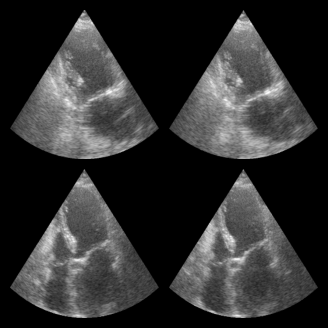

In [8]:
dataset_path = "hf://zeahub/camus-sample/val"
dataloader = zea.Dataloader(
    dataset_path,
    key="data/image/values",
    revision="v0.1.0",
    batch_size=4,
    shuffle=True,
    clip_image_range=[-60, 0],
    image_range=[-60, 0],
    normalization_range=[0, 1],
    image_size=(256, 256),
    resize_type="resize",  # or "center_crop or "random_crop"
    seed=4,
)

for batch in dataloader:
    print("Batch shape:", batch.shape)
    break  # Just show the first batch

fig, _ = zea.visualize.plot_image_grid(batch)

## Processing an example
We will now use one of the zea data files to demonstrate how to process it. A full example can be found in the [zea_pipeline_example](../pipeline/zea_pipeline_example.ipynb) notebook. Here we will just show a simple example for completeness. We will start by loading a config file, that contains all the required information to initiate a processing pipeline.

In [9]:
config = zea.Config.from_path(config_picmus_iq, revision="v0.1.0a1")

config_picmus_iq.yaml: 0.00B [00:00, ?B/s]

Now we can load the zea data file, extract data and parameters, and then process the data using the pipeline defined by the config file.

In [10]:
with zea.File(file_path, mode="r", revision="v0.1.0") as file:
    parameters = file.load_parameters()
    # we use config here to overwrite some of the scan parameters
    parameters.update(**config.parameters)
    data = file.data.raw_data[:]

pipeline = zea.Pipeline.from_config(config)
inputs = pipeline.prepare_parameters(parameters)

images = pipeline(data=data, **inputs)["data"]
images = keras.ops.convert_to_numpy(images)

Finally we can plot the result.

Text(0, 0.5, 'Z (mm)')

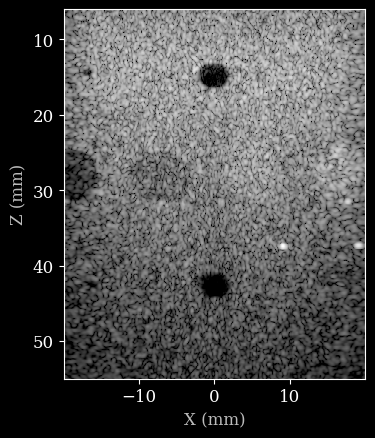

In [11]:
image = zea.display.to_8bit(images[0], dynamic_range=(-50, 0))
plt.figure()
# Convert xlims and zlims from meters to millimeters for display
xlims_mm = [v * 1e3 for v in parameters.xlims]
zlims_mm = [v * 1e3 for v in parameters.zlims]
plt.imshow(image, cmap="gray", extent=[xlims_mm[0], xlims_mm[1], zlims_mm[1], zlims_mm[0]])
plt.xlabel("X (mm)")
plt.ylabel("Z (mm)")